# Notebook 5: External Validation and Final Results

## In this notebook, the following activities are conducted

- The final out-of-fold Random Forest predictions produced in Notebook 4 are loaded and validated.
- The completeness of the company names, TRBC sectors, Actual Final RQI, Predicted Final RQI and LSEG ESG scores is confirmed.
- The observed numerical ranges of Final RQI and LSEG ESG Score are reported without assuming that LSEG uses the same measurement scale.
- Actual Final RQI, Predicted Final RQI and LSEG ESG Score are converted into percentile ranks for comparable visual presentation.
- Spearman’s rank correlation is used because it compares company rankings and does not require the variables to have identical numerical scales.
- Actual Final RQI is compared with Predicted Final RQI.
- Actual Final RQI is compared with LSEG ESG Score.
- Predicted Final RQI is compared with LSEG ESG Score.
- The Benjamini–Hochberg adjustment is applied to the validation tests.
- External-validation relationships are presented using statistical tables and visualisations.
- A final validation workbook containing the principal Chapter 4 results is exported.

**Sample size:** 100 companies  
**Internal reporting-quality measure:** Final RQI  
**Model output:** Out-of-fold Random Forest predictions  
**External benchmark:** LSEG ESG Score  
**Statistical method:** Spearman’s rank correlation  
**Visual comparison scale:** Percentile ranks from 0 to 100  
**Main output file:** `Notebook05_Final_External_Validation_Output.xlsx`

## 1. Set Up the Project and Load the Model Predictions

The project folders are defined and the final out-of-fold model predictions produced in Notebook 4 are loaded for external validation.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_COLOUR = "#1F4E78"

PROJECT_FOLDER = Path.home() / "Desktop" / "ESGProjectAnalysis"
DATA_FOLDER = PROJECT_FOLDER / "data"
OUTPUT_FOLDER = PROJECT_FOLDER / "output"

input_file = (
    DATA_FOLDER / "Notebook05_Final_Model_Predictions.xlsx"
)

if not input_file.exists():
    raise FileNotFoundError(f"Input file not found: {input_file}")

validation_df = pd.read_excel(
    input_file,
    sheet_name="Model Predictions"
)

print(f"Companies loaded: {len(validation_df)}")
print(f"Dataset shape: {validation_df.shape}")

display(validation_df.head())

Companies loaded: 100
Dataset shape: (100, 9)


,Final Sample ID,Company Name,TRBC Sector,LSEG ESG Score,Actual Final RQI,Predicted Final RQI,Prediction Error,Absolute Error,Selected Model
0,F001,Atalaya Mining Copper SA,Basic Materials,3.033797,62.50,68.534606,-6.034606,6.034606,Random Forest
1,F002,Croda International PLC,Basic Materials,3.686486,87.50,78.156542,9.343458,9.343458,Random Forest
2,F003,Glencore PLC,Basic Materials,3.812741,62.50,73.118358,-10.618358,10.618358,Random Forest
3,F004,Hill & Smith PLC,Basic Materials,2.492386,62.50,77.358809,-14.858809,14.858809,Random Forest
4,F005,Mondi PLC,Basic Materials,3.625000,81.25,77.933131,3.316869,3.316869,Random Forest


## 2. Validate the External-Validation Dataset

The external-validation dataset is checked for sample size, company uniqueness, missing values and valid RQI ranges. The observed LSEG ESG Score range is reported without assuming that it uses the same numerical scale as Final RQI.

In [2]:
required_columns = [
    "Final Sample ID",
    "Company Name",
    "TRBC Sector",
    "Actual Final RQI",
    "Predicted Final RQI",
    "LSEG ESG Score"
]

missing_columns = [
    column for column in required_columns
    if column not in validation_df.columns
]

if missing_columns:
    raise KeyError(f"Missing columns: {missing_columns}")

numerical_columns = [
    "Actual Final RQI",
    "Predicted Final RQI",
    "LSEG ESG Score"
]

validation_df[numerical_columns] = (
    validation_df[numerical_columns]
    .apply(pd.to_numeric, errors="coerce")
)

validation_summary = pd.DataFrame({
    "Validation Check": [
        "Companies loaded",
        "Unique company names",
        "Missing required values",
        "Actual RQI values within 0–100",
        "Predicted RQI values within 0–100"
    ],
    "Result": [
        len(validation_df),
        validation_df["Company Name"].nunique(),
        int(validation_df[required_columns].isna().sum().sum()),
        int(validation_df["Actual Final RQI"].between(0, 100).sum()),
        int(validation_df["Predicted Final RQI"].between(0, 100).sum())
    ]
})

display(validation_summary.style.hide(axis="index"))

if (
    len(validation_df) != 100
    or validation_df["Company Name"].nunique() != 100
    or validation_df[required_columns].isna().sum().sum() > 0
    or not validation_df["Actual Final RQI"].between(0, 100).all()
    or not validation_df["Predicted Final RQI"].between(0, 100).all()
):
    raise ValueError("External-validation dataset validation failed.")

print("\nOBSERVED SCORE RANGES")
print("-" * 35)

for column in numerical_columns:
    print(
        f"{column}: "
        f"{validation_df[column].min():.4f} to "
        f"{validation_df[column].max():.4f}"
    )

print("\nExternal-validation dataset validation passed.")

Validation Check,Result
Companies loaded,100
Unique company names,100
Missing required values,0
Actual RQI values within 0–100,100
Predicted RQI values within 0–100,100



OBSERVED SCORE RANGES
-----------------------------------
Actual Final RQI: 6.2500 to 93.7500
Predicted Final RQI: 27.2042 to 80.5503
LSEG ESG Score: 0.9564 to 4.4228

External-validation dataset validation passed.


## 3. Convert the Validation Measures into Percentile Ranks

Actual Final RQI, Predicted Final RQI and LSEG ESG Score are converted into percentile ranks ranging from 0 to 100. This creates a common visual comparison scale without assuming that the original LSEG score has the same measurement range or meaning as Final RQI. The original scores remain unchanged.


In [3]:
percentile_columns = {
    "Actual Final RQI": "Actual RQI Percentile",
    "Predicted Final RQI": "Predicted RQI Percentile",
    "LSEG ESG Score": "LSEG ESG Percentile"
}

for original_column, percentile_column in percentile_columns.items():
    validation_df[percentile_column] = (
        validation_df[original_column]
        .rank(method="average", pct=True)
        * 100
    )

percentile_validation = pd.DataFrame({
    "Measure": list(percentile_columns.values()),
    "Minimum Percentile": [
        validation_df[column].min()
        for column in percentile_columns.values()
    ],
    "Maximum Percentile": [
        validation_df[column].max()
        for column in percentile_columns.values()
    ],
    "Missing Values": [
        validation_df[column].isna().sum()
        for column in percentile_columns.values()
    ]
})

display(
    validation_df[
        [
            "Company Name",
            "Actual Final RQI",
            "Predicted Final RQI",
            "LSEG ESG Score",
            "Actual RQI Percentile",
            "Predicted RQI Percentile",
            "LSEG ESG Percentile"
        ]
    ].head()
)

print("\nPERCENTILE VALIDATION")
print(
    percentile_validation
    .round(2)
    .to_string(index=False)
)

,Company Name,Actual Final RQI,Predicted Final RQI,LSEG ESG Score,Actual RQI Percentile,Predicted RQI Percentile,LSEG ESG Percentile
0,Atalaya Mining Copper SA,62.50,68.534606,3.033797,43.0,48.0,63.0
1,Croda International PLC,87.50,78.156542,3.686486,93.0,92.0,87.0
2,Glencore PLC,62.50,73.118358,3.812741,43.0,68.0,91.0
3,Hill & Smith PLC,62.50,77.358809,2.492386,43.0,90.0,40.0
4,Mondi PLC,81.25,77.933131,3.625000,81.5,91.0,85.0



PERCENTILE VALIDATION
                 Measure  Minimum Percentile  Maximum Percentile  Missing Values
   Actual RQI Percentile                 1.5               100.0               0
Predicted RQI Percentile                 1.0               100.0               0
     LSEG ESG Percentile                 1.0               100.0               0


### Interpretation of the Percentile-Rank Validation

The percentile transformation is completed successfully for all 100 companies, with no missing values. Predicted RQI and LSEG ESG Score range from the 1st to the 100th percentile. Actual RQI begins at the 1.5th percentile because two or more companies share the lowest RQI score. The average-rank method assigns tied companies the average of their corresponding percentile positions rather than forcing an artificial ranking between identical scores.

The transformation places the three measures on a common 0–100 ranking scale without changing their original values or assuming that Final RQI and LSEG ESG Score measure exactly the same construct. Percentile ranks preserve the relative ordering of companies but do not preserve the original numerical distances between scores. They are therefore used for comparable visual presentation, while Spearman correlation provides the formal external-validation test.


## 4. Conduct the Spearman External-Validation Tests

Spearman’s rank correlation is used to assess the agreement among Actual Final RQI, Predicted Final RQI and LSEG ESG Score. The comparison between Predicted Final RQI and LSEG ESG Score provides the principal test of the second research question. The Benjamini–Hochberg procedure controls the false-discovery rate across the three comparisons.

In [4]:
from scipy.stats import spearmanr

def benjamini_hochberg(p_values):
    p_values = np.asarray(p_values, dtype=float)
    number_of_tests = len(p_values)
    order = np.argsort(p_values)
    ranked_values = p_values[order]

    adjusted_ranked = (
        ranked_values
        * number_of_tests
        / np.arange(1, number_of_tests + 1)
    )

    adjusted_ranked = np.minimum.accumulate(
        adjusted_ranked[::-1]
    )[::-1]

    adjusted_values = np.empty(number_of_tests)
    adjusted_values[order] = np.clip(
        adjusted_ranked,
        0,
        1
    )

    return adjusted_values

validation_comparisons = [
    {
        "Comparison": "Actual RQI vs Predicted RQI",
        "First Variable": "Actual Final RQI",
        "Second Variable": "Predicted Final RQI",
        "Research Purpose": "Internal predictive agreement"
    },
    {
        "Comparison": "Actual RQI vs LSEG ESG Score",
        "First Variable": "Actual Final RQI",
        "Second Variable": "LSEG ESG Score",
        "Research Purpose": "RQI benchmark validation"
    },
    {
        "Comparison": "Predicted RQI vs LSEG ESG Score",
        "First Variable": "Predicted Final RQI",
        "Second Variable": "LSEG ESG Score",
        "Research Purpose": "Primary RQ2 external validation"
    }
]

validation_records = []

for comparison in validation_comparisons:
    coefficient, p_value = spearmanr(
        validation_df[comparison["First Variable"]],
        validation_df[comparison["Second Variable"]]
    )

    validation_records.append({
        "Comparison": comparison["Comparison"],
        "Research Purpose": comparison["Research Purpose"],
        "Sample Size": len(validation_df),
        "Spearman Coefficient": coefficient,
        "P-Value": p_value
    })

external_validation_results = pd.DataFrame(
    validation_records
)

external_validation_results["Adjusted P-Value"] = (
    benjamini_hochberg(
        external_validation_results["P-Value"]
    )
)

external_validation_results["Statistically Significant"] = np.where(
    external_validation_results["Adjusted P-Value"] < 0.05,
    "Yes",
    "No"
)

external_validation_results.to_excel(
    DATA_FOLDER / "Notebook05_External_Validation_Results.xlsx",
    index=False
)

print(
    external_validation_results
    .round(4)
    .to_string(index=False)
)

                     Comparison                Research Purpose  Sample Size  Spearman Coefficient  P-Value  Adjusted P-Value Statistically Significant
    Actual RQI vs Predicted RQI   Internal predictive agreement          100                0.7878      0.0               0.0                       Yes
   Actual RQI vs LSEG ESG Score        RQI benchmark validation          100                0.5061      0.0               0.0                       Yes
Predicted RQI vs LSEG ESG Score Primary RQ2 external validation          100                0.5129      0.0               0.0                       Yes


### Statistical Interpretation of the External-Validation Results

Actual Final RQI and Predicted Final RQI show a strong positive relationship (\(r_s=0.788,\ p<0.001\)). This indicates that the out-of-fold Random Forest predictions reproduce the relative ranking of companies in the constructed reporting-quality index reasonably well. The relationship is strong but not perfect, which is consistent with the prediction errors reported in Notebook 4.

Actual Final RQI has a moderate positive relationship with LSEG ESG Score (\(r_s=0.506,\ p<0.001\)). Predicted Final RQI also has a moderate positive relationship with LSEG ESG Score (\(r_s=0.513,\ p<0.001\)). The primary test for RQ2 therefore shows that companies receiving higher model-predicted reporting-quality scores generally also receive higher LSEG ESG scores. This provides evidence of moderate external or convergent validity, but it does not demonstrate complete agreement because LSEG ESG Score and Final RQI are constructed using different data, methods and conceptual criteria.

The p-values displayed as 0.0000 result from rounding and should be reported as \(p<0.001\), not as exactly zero. All three relationships remain statistically significant after the Benjamini–Hochberg adjustment. The small difference between the two LSEG correlations, 0.506 and 0.513, should not be interpreted as a meaningful improvement without a formal test comparing dependent correlations. Overall, the results answer RQ2 by demonstrating statistically significant but moderate alignment between the machine-learning predictions and the external LSEG benchmark.


## 5. Visualise the External-Validation Relationships

The relationships between the reporting-quality measures and LSEG ESG Score are presented using percentile ranks. The first chart evaluates the constructed Final RQI against LSEG, while the second chart provides the principal visual assessment of RQ2 by comparing the model predictions with LSEG.

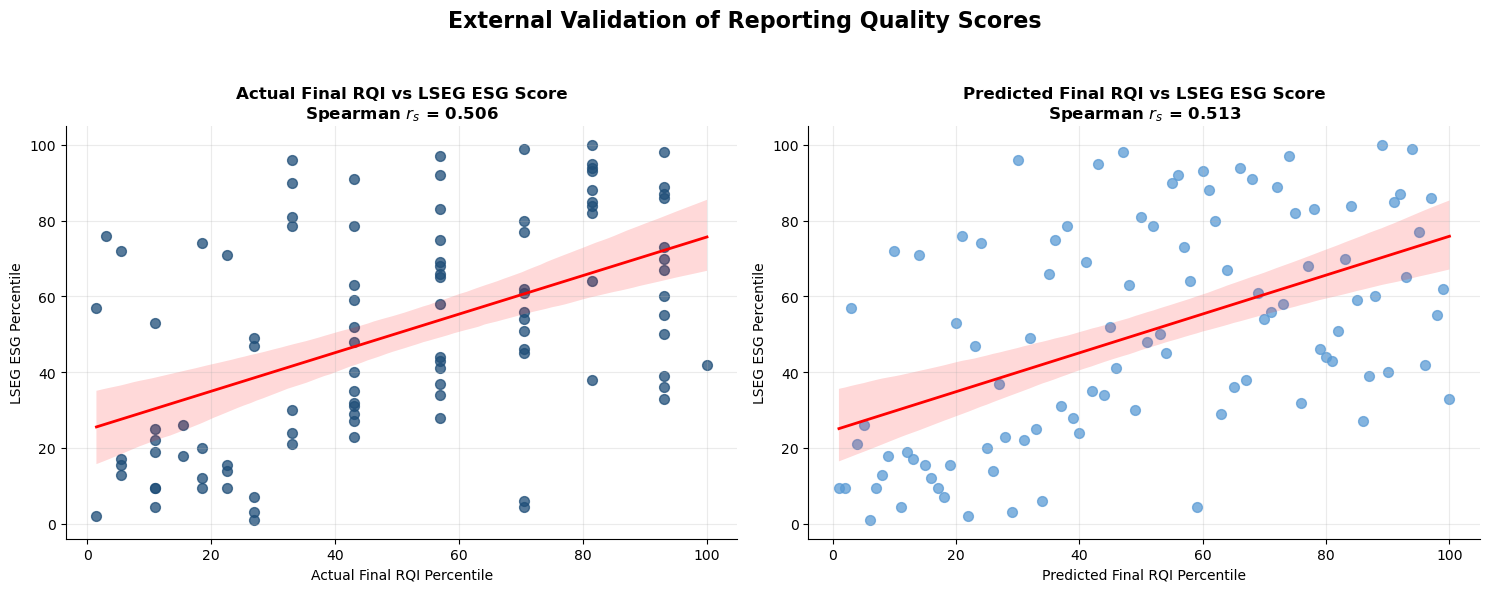

Chart saved as: Notebook05_External_Validation_Charts.png


In [5]:
actual_lseg_coefficient = external_validation_results.loc[
    external_validation_results["Comparison"]
    == "Actual RQI vs LSEG ESG Score",
    "Spearman Coefficient"
].iloc[0]

predicted_lseg_coefficient = external_validation_results.loc[
    external_validation_results["Comparison"]
    == "Predicted RQI vs LSEG ESG Score",
    "Spearman Coefficient"
].iloc[0]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 6)
)

sns.regplot(
    data=validation_df,
    x="Actual RQI Percentile",
    y="LSEG ESG Percentile",
    scatter_kws={
        "color": PROJECT_COLOUR,
        "alpha": 0.75,
        "s": 50
    },
    line_kws={
        "color": "red",
        "linewidth": 2
    },
    ax=axes[0]
)

axes[0].set_title(
    "Actual Final RQI vs LSEG ESG Score\n"
    f"Spearman $r_s$ = {actual_lseg_coefficient:.3f}",
    fontweight="bold"
)
axes[0].set_xlabel("Actual Final RQI Percentile")
axes[0].set_ylabel("LSEG ESG Percentile")

sns.regplot(
    data=validation_df,
    x="Predicted RQI Percentile",
    y="LSEG ESG Percentile",
    scatter_kws={
        "color": "#5B9BD5",
        "alpha": 0.75,
        "s": 50
    },
    line_kws={
        "color": "red",
        "linewidth": 2
    },
    ax=axes[1]
)

axes[1].set_title(
    "Predicted Final RQI vs LSEG ESG Score\n"
    f"Spearman $r_s$ = {predicted_lseg_coefficient:.3f}",
    fontweight="bold"
)
axes[1].set_xlabel("Predicted Final RQI Percentile")
axes[1].set_ylabel("LSEG ESG Percentile")

for axis in axes:
    axis.spines[["top", "right"]].set_visible(False)
    axis.grid(alpha=0.25)

plt.suptitle(
    "External Validation of Reporting Quality Scores",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.94])

validation_chart = (
    OUTPUT_FOLDER / "Notebook05_External_Validation_Charts.png"
)

plt.savefig(
    validation_chart,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Chart saved as: {validation_chart.name}")

### Interpretation of the External-Validation Visualisation

Both charts show upward trends, indicating that companies with higher reporting-quality percentiles generally also have higher LSEG ESG percentiles. Actual Final RQI has a moderate positive relationship with LSEG ESG Score (\(r_s=0.506\)), while Predicted Final RQI has a similar moderate relationship (\(r_s=0.513\)). The vertical concentrations of observations in the first chart occur because Final RQI is constructed from discrete criterion scores, causing several companies to share the same RQI percentile. The model predictions are more continuous, which produces a more dispersed horizontal distribution in the second chart.

The substantial spread of observations around both trend lines shows that the relationships are not exact. Some companies receive high reporting-quality rankings but comparatively low LSEG rankings, while others show the opposite pattern. This is expected because Final RQI evaluates evidence contained in corporate reports, whereas LSEG ESG Score may also incorporate broader sustainability-performance, controversy and governance information. The visual evidence therefore supports moderate external validity and answers RQ2 by showing meaningful, statistically significant alignment without implying that the two measures are interchangeable.

## 6. Create the Final External-Validation Workbook

The external-validation statistics, company-level percentile results, model comparison and NLP feature-importance results are consolidated into a final workbook. This provides the principal statistical tables required for reporting the findings.


In [6]:
actual_predicted_coefficient = external_validation_results.loc[
    external_validation_results["Comparison"]
    == "Actual RQI vs Predicted RQI",
    "Spearman Coefficient"
].iloc[0]

validation_summary_results = pd.DataFrame({
    "Validation Measure": [
        "Companies externally validated",
        "Actual RQI vs Predicted RQI",
        "Actual RQI vs LSEG ESG Score",
        "Predicted RQI vs LSEG ESG Score",
        "Difference between LSEG correlations"
    ],
    "Result": [
        len(validation_df),
        actual_predicted_coefficient,
        actual_lseg_coefficient,
        predicted_lseg_coefficient,
        predicted_lseg_coefficient - actual_lseg_coefficient
    ]
})

company_validation_results = validation_df[
    [
        "Final Sample ID",
        "Company Name",
        "TRBC Sector",
        "Actual Final RQI",
        "Predicted Final RQI",
        "LSEG ESG Score",
        "Actual RQI Percentile",
        "Predicted RQI Percentile",
        "LSEG ESG Percentile"
    ]
].copy()

model_comparison_file = (
    DATA_FOLDER / "Notebook04_Model_Performance_Comparison.xlsx"
)

feature_importance_file = (
    DATA_FOLDER / "Notebook04_Random_Forest_Feature_Importance.xlsx"
)

model_comparison_results = pd.read_excel(
    model_comparison_file
)

feature_importance_results = pd.read_excel(
    feature_importance_file
)

final_output_file = (
    DATA_FOLDER / "Notebook05_Final_External_Validation_Output.xlsx"
)

with pd.ExcelWriter(
    final_output_file,
    engine="openpyxl"
) as writer:
    validation_summary_results.to_excel(
        writer,
        sheet_name="Validation Summary",
        index=False
    )
    external_validation_results.to_excel(
        writer,
        sheet_name="Correlation Results",
        index=False
    )
    company_validation_results.to_excel(
        writer,
        sheet_name="Company Results",
        index=False
    )
    model_comparison_results.to_excel(
        writer,
        sheet_name="Model Comparison",
        index=False
    )
    feature_importance_results.to_excel(
        writer,
        sheet_name="Feature Importance",
        index=False
    )

print(
    validation_summary_results
    .round(4)
    .to_string(index=False)
)

if (
    len(company_validation_results) != 100
    or company_validation_results.isna().sum().sum() > 0
    or not external_validation_results[
        "Statistically Significant"
    ].eq("Yes").all()
):
    raise ValueError("Notebook 5 final validation failed.")

print("\nNotebook 5 validation passed.")
print("External-validation analysis is complete.")
print(f"Final workbook saved as: {final_output_file.name}")
print(f"Final chart saved as: {validation_chart.name}")

                  Validation Measure   Result
      Companies externally validated 100.0000
         Actual RQI vs Predicted RQI   0.7878
        Actual RQI vs LSEG ESG Score   0.5061
     Predicted RQI vs LSEG ESG Score   0.5129
Difference between LSEG correlations   0.0068

Notebook 5 validation passed.
External-validation analysis is complete.
Final workbook saved as: Notebook05_Final_External_Validation_Output.xlsx
Final chart saved as: Notebook05_External_Validation_Charts.png


### Statistical Interpretation of the Final External Validation

External validation is completed for all 100 companies. The strong positive correlation between Actual RQI and Predicted RQI (\(r_s = 0.7878\)) indicates that the predictive model effectively reproduces the relative ranking of reporting quality. This provides evidence of strong internal predictive agreement.

Actual RQI has a moderate positive correlation with the LSEG ESG Score (\(r_s = 0.5061\)), while Predicted RQI has a slightly stronger moderate correlation with LSEG (\(r_s = 0.5129\)). The small difference of 0.0068 indicates that the model retains almost the same level of external alignment as the observed RQI. Overall, the findings support the external validity of the model while demonstrating that RQI and LSEG measure related, but not identical, aspects of corporate ESG reporting and performance.


## 7. Notebook Summary and Reproducibility Note

This notebook completes the external validation of the Reporting Quality Index and the Random Forest predictions for 100 companies. Because Final RQI and LSEG ESG Scores are measured on different numerical scales, percentile ranks are used for visual comparison, while Spearman’s rank correlation is used for the formal statistical evaluation.

A strong positive relationship is identified between Actual RQI and Predicted RQI (\(r_s = 0.7878\), \(p < 0.001\)), demonstrating strong predictive agreement. Actual RQI has a moderate positive relationship with the LSEG ESG Score (\(r_s = 0.5061\), \(p < 0.001\)), while Predicted RQI also has a moderate positive relationship with LSEG (\(r_s = 0.5129\), \(p < 0.001\)). The small difference of 0.0068 between the two LSEG correlations indicates that the model preserves the external alignment observed in the actual RQI.

The findings provide evidence of moderate external validity and answer the second research question. However, RQI and LSEG ESG Scores are interpreted as related rather than equivalent measures because they assess different aspects of corporate reporting and ESG performance.

Reproducibility is supported through the validated 100-company sample, fixed analytical variables, percentile transformation, Spearman correlation, multiple-testing adjustment and systematically saved outputs.

The following files are produced:

- `Notebook05_External_Validation_Results.xlsx`
- `Notebook05_Final_External_Validation_Output.xlsx`
- `Notebook05_External_Validation_Charts.png`

The external-validation analysis and the five-notebook analytical workflow are complete.
